# Patch-embedding analysis: rgb / rgbd_early / rgbd_dca (K=0,1,2)

Inspects what each variant does at the **very first layer** of the Swin backbone
(`patch_embed`, plus the `DCAFusion` step for the DCA variants).

This notebook is **standalone torch only** - it does not import detectron2 or
Mask2Former and needs no GPU. It loads just the `patch_embed*` / `fusion`
sub-weights from each `model_final.pth` into small reconstructed modules and
runs them on CPU.

**Three questions:**
1. *Did the model learn to use depth at all?* (weight-space: depth channel / fusion value-projection norms that started at zero)
2. *What structure do the patch embeddings have?* (PCA->RGB of the tokens entering the transformer)
3. *Where does depth change the representation?* (relative depth-contribution heatmaps)

> **Caveat:** absolute embeddings are **not comparable across separately-trained
> models** (each learns its own basis). PCA colours are only meaningful
> *within* a variant. The depth-contribution maps (Q3) and the zero-init weight
> diagnostics (Q1) *are* comparable across models because they are normalized
> and measured against each model's own RGB-only baseline state.

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

torch.set_grad_enabled(False)
plt.rcParams['figure.dpi'] = 110

## Config

Edit `RUNS` to add/remove variants. `type` is one of `rgb` / `early` / `dca`; `K` is the DCA iteration count.

In [3]:
ROOT = Path('.').resolve()
DATA = ROOT / 'data' / 'Rob2Pheno'
RGB_DIR, DEPTH_DIR = DATA / 'RGB', DATA / 'Depth'
TRAIN_JSON, VAL_JSON = DATA / 'train_2class.JSON', DATA / 'val_2class.JSON'

RUNS = {
    'rgb':            dict(dir='rgb_mi8000_sz1280_sz1280_swin_tiny',             type='rgb',   K=0),
    'rgbd_early':     dict(dir='rgbd_early_mi8000_sz1280_fixed_depth_swin_tiny', type='early', K=0),
    'rgbd_dca (K=0)': dict(dir='rgbd_dca_iter0_mi8000_sz1280_sz1280_swin_tiny',  type='dca',   K=0),
    'rgbd_dca (K=1)': dict(dir='rgbd_dca_iter1_mi8000_sz1280_sz1280_swin_tiny',  type='dca',   K=1),
    'rgbd_dca (K=2)': dict(dir='rgbd_dca_iter2_mi8000_sz1280_sz1280_swin_tiny',  type='dca',   K=2),
}
for r in RUNS.values():
    r['ckpt'] = ROOT / 'output' / r['dir'] / 'model_final.pth'
    assert r['ckpt'].exists(), f"missing {r['ckpt']}"

# Must match training preprocessing. Mask2Former Swin uses INPUT.FORMAT='RGB'
# with ImageNet RGB-order pixel stats.
PIXEL_MEAN_RGB = np.array([123.675, 116.280, 103.530], dtype=np.float32)
PIXEL_STD_RGB  = np.array([58.395, 57.120, 57.375], dtype=np.float32)
MIN_SIZE_TEST, MAX_SIZE_TEST = 1024, 1280   # sz1280 training-time test resize
PATCH, EMBED_DIM = 4, 96
print('checkpoints present for:', list(RUNS))

checkpoints present for: ['rgb', 'rgbd_early', 'rgbd_dca (K=0)', 'rgbd_dca (K=1)', 'rgbd_dca (K=2)']


## Depth normalization stats

Replicates `_compute_depth_stats` from [variants/rgbd_early.py](variants/rgbd_early.py): mean/std over **valid** (non-zero) depth pixels of the **training-split** TIFFs. Zero is the sensor's invalid sentinel and is excluded.

In [4]:
def _depth_path(rgb_name):
    return DEPTH_DIR / rgb_name.replace('_RGB.tiff', '_DEPTH.tiff')

def _train_depth_paths():
    coco = json.load(open(TRAIN_JSON))
    paths = [_depth_path(im['file_name']) for im in coco['images']]
    paths = sorted({p for p in paths if p.exists()})
    assert paths, 'no training depth tiffs found'
    return paths

def compute_depth_stats():
    s = sq = n = 0.0
    for p in _train_depth_paths():
        d = np.asarray(Image.open(p).convert('L'), dtype=np.float64)
        v = d[d > 0]
        s += v.sum(); sq += (v ** 2).sum(); n += v.size
    mean = s / n
    return float(mean), float(np.sqrt(sq / n - mean ** 2))

DEPTH_MEAN, DEPTH_STD = compute_depth_stats()
DEPTH_FILL = float(np.clip(round(DEPTH_MEAN), 0, 255))
print(f'depth: mean={DEPTH_MEAN:.3f} std={DEPTH_STD:.3f} fill={DEPTH_FILL:.0f}')

depth: mean=127.181 std=73.239 fill=127


## Preprocessing

Resize (shortest-edge, matching detectron2 `ResizeShortestEdge`), fill invalid depth, normalize per channel, pad to a multiple of the patch size. Returns the 4-channel input tensor plus display copies.

In [5]:
def _resize_dims(h, w):
    scale = MIN_SIZE_TEST / min(h, w)
    if max(h, w) * scale > MAX_SIZE_TEST:
        scale = MAX_SIZE_TEST / max(h, w)
    return round(h * scale), round(w * scale)

def load_input(rgb_name):
    rgb = np.asarray(Image.open(RGB_DIR / rgb_name).convert('RGB'), dtype=np.uint8)
    raw_depth = np.asarray(Image.open(_depth_path(rgb_name)).convert('L'), dtype=np.uint8)
    depth = np.where(raw_depth > 0, raw_depth, DEPTH_FILL).astype(np.uint8)
    h, w = rgb.shape[:2]
    nh, nw = _resize_dims(h, w)
    rgb_r = np.asarray(Image.fromarray(rgb).resize((nw, nh), Image.BILINEAR), dtype=np.float32)
    depth_r = np.asarray(Image.fromarray(depth).resize((nw, nh), Image.NEAREST), dtype=np.float32)
    rgb_n = (rgb_r - PIXEL_MEAN_RGB) / PIXEL_STD_RGB
    depth_n = (depth_r - DEPTH_MEAN) / DEPTH_STD
    x = np.concatenate([rgb_n, depth_n[..., None]], axis=-1)
    ph, pw = (-nh) % PATCH, (-nw) % PATCH
    x = np.pad(x, ((0, ph), (0, pw), (0, 0)))
    t = torch.from_numpy(x.transpose(2, 0, 1)).float().unsqueeze(0)  # (1,4,H,W)
    grid = (t.shape[-2] // PATCH, t.shape[-1] // PATCH)
    return t, rgb_r.astype(np.uint8), depth_r.astype(np.uint8), grid

## Reconstructed modules

`PatchEmbed` mirrors Mask2Former's Swin patch embed (conv + LayerNorm). `DCAFusion` is copied verbatim from [variants/rgbd_dca.py](variants/rgbd_dca.py) so the forward pass is identical to training. Trained weights are loaded into these from each checkpoint's `state_dict`.

In [6]:
class PatchEmbed(nn.Module):
    def __init__(self, in_chans, embed_dim=EMBED_DIM, patch=PATCH):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch, stride=patch)
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        x = self.proj(x)                    # B,C,Wh,Ww
        grid = (x.shape[2], x.shape[3])
        x = x.flatten(2).transpose(1, 2)    # B,N,C
        return self.norm(x), grid

class _IterBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        for n in ['W_Iq', 'W_Ik', 'W_Dv', 'W_Dq', 'W_Dk', 'W_Iv']:
            setattr(self, n, nn.Linear(d, d, bias=False))

class DCAFusion(nn.Module):
    def __init__(self, d=EMBED_DIM, num_iters=0):
        super().__init__()
        self.W_D1 = nn.Linear(d, d, bias=False)
        self.W_D2 = nn.Linear(d, d, bias=False)
        self.W_I1 = nn.Linear(d, d, bias=False)
        self.iter_blocks = nn.ModuleList([_IterBlock(d) for _ in range(num_iters)])
    def _attend(self, Qs, Ks, Vs, Wq, Wk, Wv, residual):
        Q, K, V = Wq(Qs).unsqueeze(1), Wk(Ks).unsqueeze(1), Wv(Vs).unsqueeze(1)
        return residual + F.scaled_dot_product_attention(Q, K, V).squeeze(1)
    def forward(self, rgb, depth):
        rgb = self._attend(depth, depth, rgb, self.W_D1, self.W_D2, self.W_I1, rgb)
        for b in self.iter_blocks:
            depth = self._attend(rgb, rgb, depth, b.W_Iq, b.W_Ik, b.W_Dv, depth)
            rgb = self._attend(depth, depth, rgb, b.W_Dq, b.W_Dk, b.W_Iv, rgb)
        return rgb, depth

In [7]:
def _load_sd(run):
    ck = torch.load(run['ckpt'], map_location='cpu')
    return ck.get('model', ck)

def _sub(sd, prefix):
    return {k[len(prefix):]: v for k, v in sd.items() if k.startswith(prefix)}

def build_modules(run):
    sd = _load_sd(run)
    m = {}
    if run['type'] in ('rgb', 'early'):
        pe = PatchEmbed(3 if run['type'] == 'rgb' else 4)
        pe.load_state_dict(_sub(sd, 'backbone.patch_embed.'))
        m['patch_embed'] = pe.eval()
    else:
        pr = PatchEmbed(3); pr.load_state_dict(_sub(sd, 'backbone.patch_embed_rgb.'))
        pd = PatchEmbed(1); pd.load_state_dict(_sub(sd, 'backbone.patch_embed_depth.'))
        fu = DCAFusion(EMBED_DIM, run['K']); fu.load_state_dict(_sub(sd, 'backbone.fusion.'))
        m.update(patch_embed_rgb=pr.eval(), patch_embed_depth=pd.eval(), fusion=fu.eval())
    return m

def extract(run, mods, t):
    # Returns the tokens that enter the Swin stages, plus DCA pre/post-fusion.
    if run['type'] in ('rgb', 'early'):
        x = t if run['type'] == 'early' else t[:, :3]
        tok, grid = mods['patch_embed'](x)
        return dict(tokens=tok, grid=grid)
    rgb_tok, grid = mods['patch_embed_rgb'](t[:, :3])
    depth_tok, _ = mods['patch_embed_depth'](t[:, 3:])
    fused_rgb, fused_depth = mods['fusion'](rgb_tok, depth_tok)
    return dict(tokens=fused_rgb, rgb_pre=rgb_tok, fused_rgb=fused_rgb, grid=grid)

MODELS = {name: build_modules(run) for name, run in RUNS.items()}
print('loaded modules for:', list(MODELS))

loaded modules for: ['rgb', 'rgbd_early', 'rgbd_dca (K=0)', 'rgbd_dca (K=1)', 'rgbd_dca (K=2)']


## Q1a - Early fusion: did the depth channel move off zero?

`rgbd_early` zero-initialized the depth column of its `Conv2d(4->96)` patch-embed
weight, so at init it was identical to RGB-only. Per-input-channel L2 norm of the
trained weight shows whether depth now carries signal (compared against the RGB
baseline's three channels for scale).

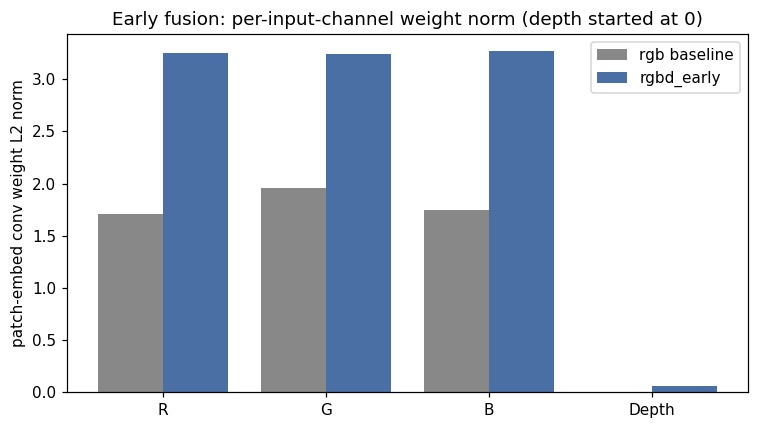

depth-channel norm = 0.058  (1.8% of mean RGB-channel norm)


In [8]:
def channel_norms(w):  # w: (out, in, kh, kw) -> per-input-channel L2 norm
    c = w.shape[1]
    return w.permute(1, 0, 2, 3).reshape(c, -1).norm(dim=1).numpy()

rgb_w = MODELS['rgb']['patch_embed'].proj.weight.detach()
early_w = MODELS['rgbd_early']['patch_embed'].proj.weight.detach()
rgb_n, early_n = channel_norms(rgb_w), channel_norms(early_w)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(np.arange(3) - 0.2, rgb_n, 0.4, label='rgb baseline', color='#888')
ax.bar(np.arange(4) + 0.2, early_n, 0.4, label='rgbd_early', color='#4a6fa5')
ax.set_xticks(range(4)); ax.set_xticklabels(['R', 'G', 'B', 'Depth'])
ax.set_ylabel('patch-embed conv weight L2 norm'); ax.legend()
ax.set_title('Early fusion: per-input-channel weight norm (depth started at 0)')
plt.tight_layout(); plt.show()
print(f'depth-channel norm = {early_n[3]:.3f}  '
      f'({100 * early_n[3] / early_n[:3].mean():.1f}% of mean RGB-channel norm)')

## Q1b - DCA: did the depth-guided value projections move off zero?

`DCAFusion` zero-initialized every projection that injects depth into the RGB/depth
streams (`W_I1`, and each iter block's `W_Iv` / `W_Dv`), with a residual so the
fused output starts identical to RGB-only. A non-zero norm means that path is now
active. `W_D1` / `W_D2` (xavier-init query/key) are shown for scale.

In [9]:
rows = []
for name in [n for n in RUNS if RUNS[n]['type'] == 'dca']:
    fu = MODELS[name]['fusion']
    rec = {'variant': name,
           'W_D1 (q,xavier)': fu.W_D1.weight.norm().item(),
           'W_D2 (k,xavier)': fu.W_D2.weight.norm().item(),
           'W_I1 (D->I val, init 0)': fu.W_I1.weight.norm().item()}
    for i, b in enumerate(fu.iter_blocks):
        rec[f'W_Dv[{i}] (I->D val, init 0)'] = b.W_Dv.weight.norm().item()
        rec[f'W_Iv[{i}] (D->I val, init 0)'] = b.W_Iv.weight.norm().item()
    rows.append(rec)
dca_w = pd.DataFrame(rows).set_index('variant')
display(dca_w.style.format('{:.3f}').background_gradient(cmap='Blues', axis=None))

,"W_D1 (q,xavier)","W_D2 (k,xavier)","W_I1 (D->I val, init 0)","W_Dv[0] (I->D val, init 0)","W_Iv[0] (D->I val, init 0)","W_Dv[1] (I->D val, init 0)","W_Iv[1] (D->I val, init 0)"
variant,,,,,,,
rgbd_dca (K=0),9.510,9.658,0.733,nan,nan,nan,nan
rgbd_dca (K=1),9.457,9.483,0.633,0.448,0.654,nan,nan
rgbd_dca (K=2),9.517,9.540,0.650,0.473,0.596,0.696,0.575


## Choose images

Default: first 3 validation images. Edit `IMAGE_NAMES` to pick specific ones.

In [10]:
val = json.load(open(VAL_JSON))
IMAGE_NAMES = [im['file_name'] for im in val['images']][:3]
print('\n'.join(IMAGE_NAMES))

RealSense_T20190528_234546_R04_P026480_H2300_A+000_RGB.tiff
RealSense_T20190528_230009_R02_P002860_H1630_A+000_RGB.tiff
RealSense_T20190528_230009_R02_P002860_H2300_A+000_RGB.tiff


## Q2 - Patch-embedding structure (PCA -> RGB)

Tokens entering the transformer, projected to 3 PCA components and shown as RGB.
Reveals what spatial structure each variant's embedding captures. **Colours are
per-model** (independent PCA bases) - compare structure, not hue, across columns.

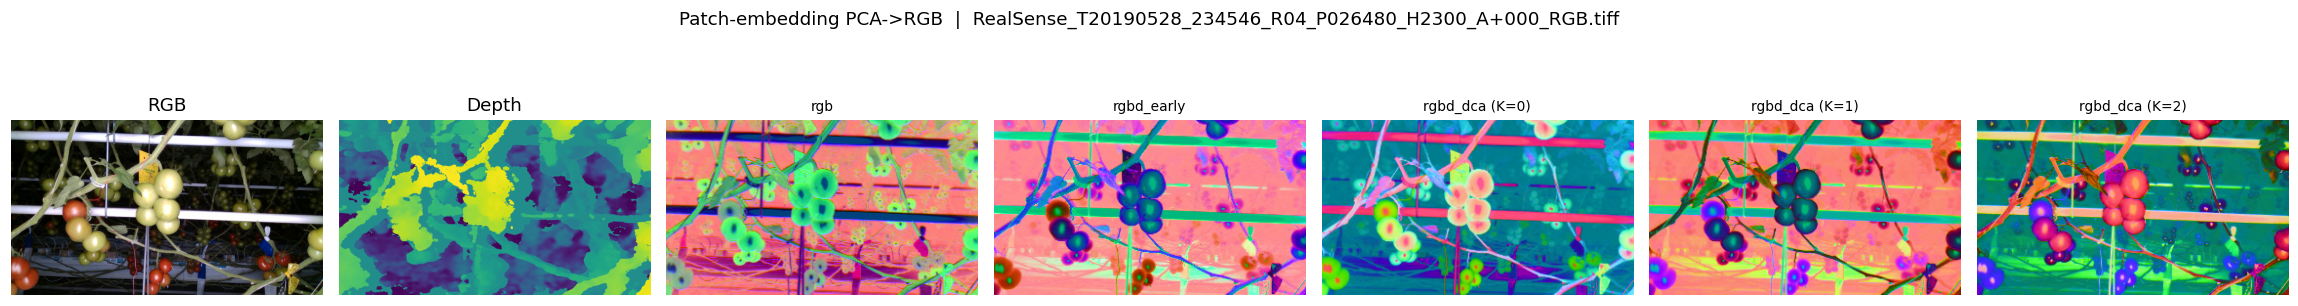

In [11]:
def pca_rgb(tokens, grid):
    X = tokens.squeeze(0).cpu().numpy()
    img = PCA(n_components=3).fit_transform(X).reshape(*grid, 3)
    lo = np.percentile(img, 2, axis=(0, 1)); hi = np.percentile(img, 98, axis=(0, 1))
    return np.clip((img - lo) / (hi - lo + 1e-8), 0, 1)

img_name = IMAGE_NAMES[0]
t, rgb_disp, depth_disp, grid = load_input(img_name)

ncol = len(RUNS) + 2
fig, ax = plt.subplots(1, ncol, figsize=(3.0 * ncol, 3.4))
ax[0].imshow(rgb_disp); ax[0].set_title('RGB'); ax[0].axis('off')
ax[1].imshow(depth_disp, cmap='viridis'); ax[1].set_title('Depth'); ax[1].axis('off')
for a, (name, run) in zip(ax[2:], RUNS.items()):
    res = extract(run, MODELS[name], t)
    a.imshow(pca_rgb(res['tokens'], res['grid']))
    a.set_title(name, fontsize=9); a.axis('off')
fig.suptitle(f'Patch-embedding PCA->RGB  |  {img_name}')
plt.tight_layout(); plt.show()

## Q3 - Where does depth change the representation?

Per-patch **relative depth contribution**, normalized so models are comparable:

- **early**: linear conv decomposition, `||conv(depth)|| / ||conv(rgb)||` per patch
  (the patch-embed conv is linear, so the depth channel's additive contribution is exact).
- **dca**: fusion delta, `||fused_rgb - rgb_pre|| / ||rgb_pre||` per patch
  (how much depth-guided cross-attention moved each RGB token off its RGB-only value).

Both answer *"where, and how much, does depth alter the tokens entering the transformer?"*
Bright = strong depth influence.

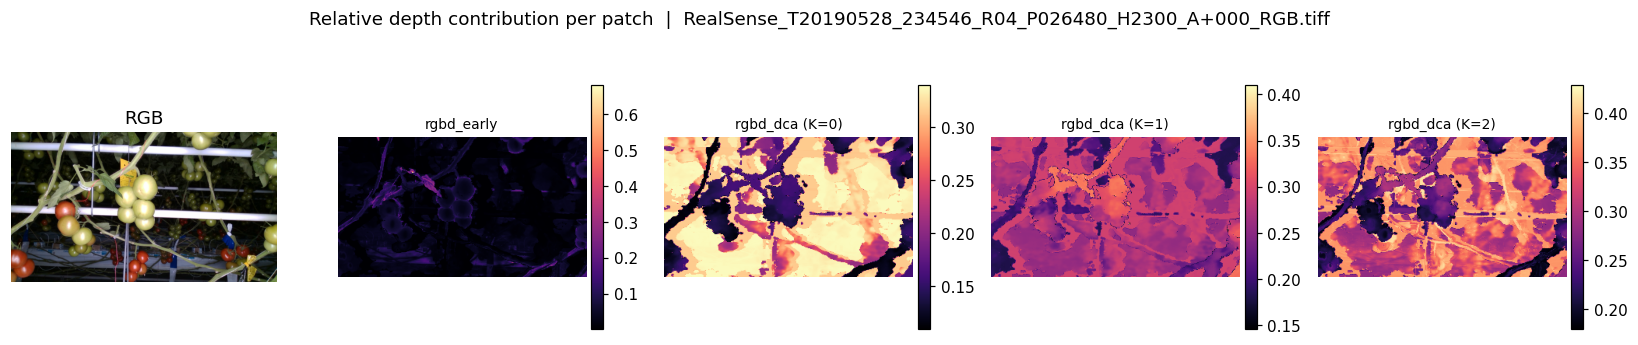

In [12]:
def early_depth_ratio(mods, t, grid):
    w = mods['patch_embed'].proj.weight
    rgb_c = F.conv2d(t[:, :3], w[:, :3], stride=PATCH)
    dep_c = F.conv2d(t[:, 3:], w[:, 3:4], stride=PATCH)
    return (dep_c.norm(dim=1) / (rgb_c.norm(dim=1) + 1e-6))[0].cpu().numpy()

def dca_delta_ratio(res):
    d = (res['fused_rgb'] - res['rgb_pre']).norm(dim=-1)
    r = res['rgb_pre'].norm(dim=-1) + 1e-6
    return (d / r).reshape(*res['grid']).cpu().numpy()

panel = [n for n in RUNS if RUNS[n]['type'] in ('early', 'dca')]
ncol = len(panel) + 1
fig, ax = plt.subplots(1, ncol, figsize=(3.0 * ncol, 3.4))
ax[0].imshow(rgb_disp); ax[0].set_title('RGB'); ax[0].axis('off')
for a, name in zip(ax[1:], panel):
    res = extract(RUNS[name], MODELS[name], t)
    if RUNS[name]['type'] == 'early':
        m = early_depth_ratio(MODELS[name], t, res['grid'])
    else:
        m = dca_delta_ratio(res)
    im = a.imshow(m, cmap='magma'); a.set_title(name, fontsize=9); a.axis('off')
    fig.colorbar(im, ax=a, fraction=0.046, pad=0.02)
fig.suptitle(f'Relative depth contribution per patch  |  {img_name}')
plt.tight_layout(); plt.show()

## Q3 across several images

The DCA fusion delta for each chosen image, to check whether the depth-driven changes are consistent or image-dependent.

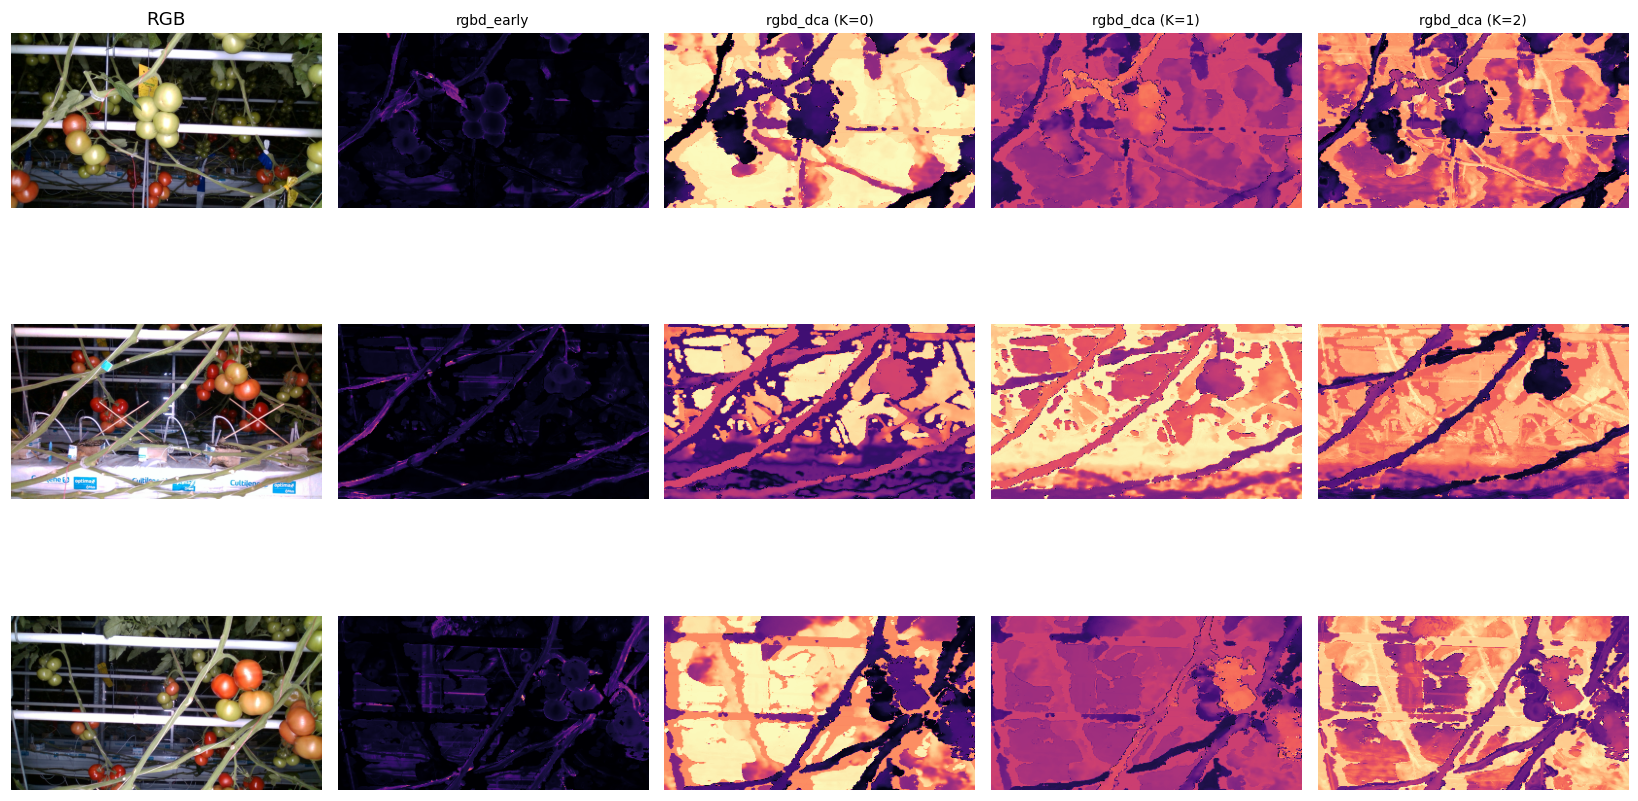

In [13]:
# Depth-influence per patch across images.
# early uses the conv ratio  ||conv(depth)||/||conv(rgb)||;
# dca uses the fusion delta  ||fused-rgb||/||rgb||.
# Each panel auto-scales independently, so read brightness WITHIN a column,
# not across the early vs dca boundary (different metrics).
panel_names = [n for n in RUNS if RUNS[n]['type'] in ('early', 'dca')]

def depth_influence(name, t):
    res = extract(RUNS[name], MODELS[name], t)
    if RUNS[name]['type'] == 'early':
        return early_depth_ratio(MODELS[name], t, res['grid'])
    return dca_delta_ratio(res)

fig, ax = plt.subplots(len(IMAGE_NAMES), len(panel_names) + 1,
                       figsize=(3.0 * (len(panel_names) + 1), 3.0 * len(IMAGE_NAMES)))
ax = np.atleast_2d(ax)
for ri, nm in enumerate(IMAGE_NAMES):
    ti, rgb_i, _, gi = load_input(nm)
    ax[ri, 0].imshow(rgb_i); ax[ri, 0].axis('off')
    if ri == 0: ax[ri, 0].set_title('RGB')
    for ci, name in enumerate(panel_names, start=1):
        im = ax[ri, ci].imshow(depth_influence(name, ti), cmap='magma')
        ax[ri, ci].axis('off')
        if ri == 0: ax[ri, ci].set_title(name, fontsize=9)
#fig.suptitle('Relative depth influence per patch  (early: conv ratio | dca: fusion delta)')
plt.tight_layout(); plt.show()

## Q4 - Basis-aligned absolute difference from the rgb baseline

The honest cross-model comparison. Naively subtracting one model's patch tokens
from another's is dominated by the fact that **each model learned its own 96-d
basis** (different LayerNorm affine, independent fine-tuning trajectories), so the
same scene lands in a rotated coordinate system. We remove that confound with
**orthogonal Procrustes**: for each variant we find the rigid rotation/reflection
`R` that best maps its tokens onto the `rgb` tokens for the *same* image, then plot
the **leftover per-patch L2 distance**.

That residual is the part of the representation change that **no basis rotation can
explain** - genuine, spatially-structured divergence from the rgb baseline (expected
to track where depth carries signal). `rgb` is the reference, so it has zero
self-difference and isn't shown as a panel.

Colour scale is **shared across all variant panels**, so brightness is comparable
column-to-column and image-to-image - unlike the per-model PCA (Q2) or the
independently-scaled ratios (Q3). The printed table reports how much of the raw
token distance was *just* an arbitrary rotation (`frac removed by rotation`); a high
value means most of the apparent difference was basis, not substance.

> **Caveats.** (1) `R` is fit per-image on the very tokens being differenced, so it
> absorbs the best global rotation - the residual is a *lower bound* on divergence.
> (2) Mean-centring drops any constant per-feature offset between models. (3) An
> orthogonal map preserves token norms but can't undo a per-channel rescaling; if
> that matters, swap `R` for a least-squares linear map (`np.linalg.lstsq(A, B)`),
> at the cost of letting the alignment overfit.

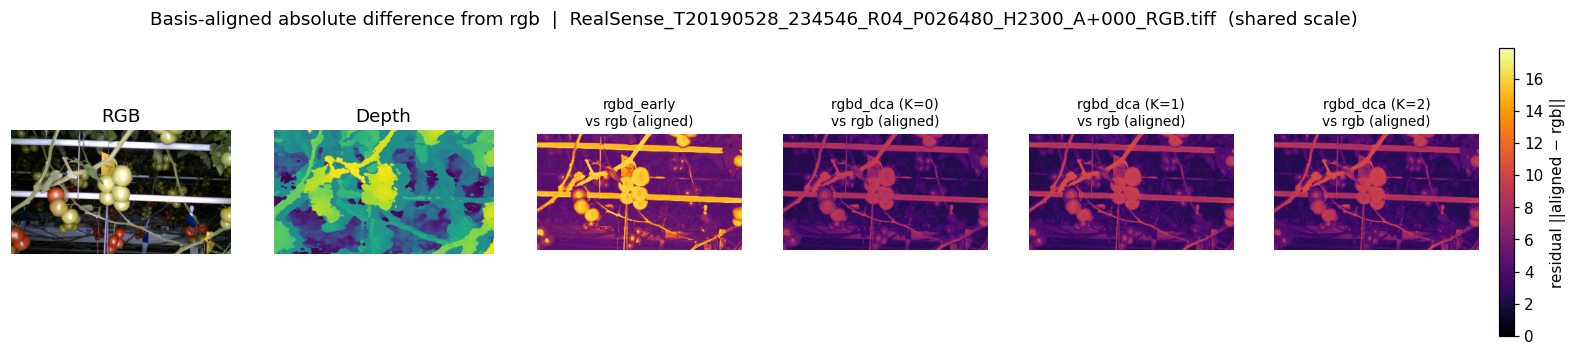

                raw mean dist  aligned residual  frac removed by rotation
variant                                                                  
rgbd_early             11.243             7.622                     0.322
rgbd_dca (K=0)          8.540             4.537                     0.469
rgbd_dca (K=1)          8.785             4.742                     0.460
rgbd_dca (K=2)          8.651             4.777                     0.448


In [14]:
def procrustes_residual(T_var, T_ref):
    """Per-patch L2 residual after rigidly aligning T_var onto T_ref.

    T_var, T_ref: (N, C) token matrices for the SAME image (identical patch
    grid, so rows correspond). Both are mean-centred, then we solve the
    orthogonal Procrustes problem -- the rotation/reflection R that minimises
    ||T_var @ R - T_ref|| -- and return the leftover per-patch distance.
    The residual is the part of the representation change that NO basis
    rotation can absorb, i.e. genuine divergence from the rgb baseline.
    Also returns the raw (unaligned) distance so we can report how much of
    the apparent difference was just an arbitrary basis rotation.
    """
    A = T_var - T_var.mean(0, keepdims=True)
    B = T_ref - T_ref.mean(0, keepdims=True)
    U, _, Vt = np.linalg.svd(A.T @ B)        # C x C, trivial (C=96)
    R = U @ Vt                               # orthogonal (reflection allowed)
    resid = np.linalg.norm(A @ R - B, axis=1)
    raw = np.linalg.norm(A - B, axis=1)
    return resid, raw

def tokens_np(name, t):
    res = extract(RUNS[name], MODELS[name], t)
    return res['tokens'].squeeze(0).cpu().numpy(), res['grid']

img_name = IMAGE_NAMES[0]
t, rgb_disp, depth_disp, grid = load_input(img_name)
ref_tok, _ = tokens_np('rgb', t)

panel = [n for n in RUNS if n != 'rgb']           # rgb is the reference (self-diff = 0)
resid_maps, raw_means = {}, []
for name in panel:
    var_tok, g = tokens_np(name, t)
    resid, raw = procrustes_residual(var_tok, ref_tok)
    resid_maps[name] = resid.reshape(*g)
    raw_means.append((name, raw.mean(), resid.mean(), 1 - resid.mean() / raw.mean()))

# Shared colour scale across variants so brightness is comparable column-to-column
vmax = max(m.max() for m in resid_maps.values())

ncol = len(panel) + 2
fig, ax = plt.subplots(1, ncol, figsize=(3.0 * ncol, 3.4))
ax[0].imshow(rgb_disp); ax[0].set_title('RGB'); ax[0].axis('off')
ax[1].imshow(depth_disp, cmap='viridis'); ax[1].set_title('Depth'); ax[1].axis('off')
im = None
for a, name in zip(ax[2:], panel):
    im = a.imshow(resid_maps[name], cmap='inferno', vmin=0, vmax=vmax)
    a.set_title(f'{name}\nvs rgb (aligned)', fontsize=9); a.axis('off')
fig.suptitle(f'Basis-aligned absolute difference from rgb  |  {img_name}  (shared scale)')
fig.colorbar(im, ax=ax[2:], fraction=0.046, pad=0.02, label='residual ||aligned − rgb||')
plt.show()

# How much of the raw token difference was just an arbitrary basis rotation?
print(pd.DataFrame(raw_means,
      columns=['variant', 'raw mean dist', 'aligned residual', 'frac removed by rotation']
      ).set_index('variant').round(3).to_string())

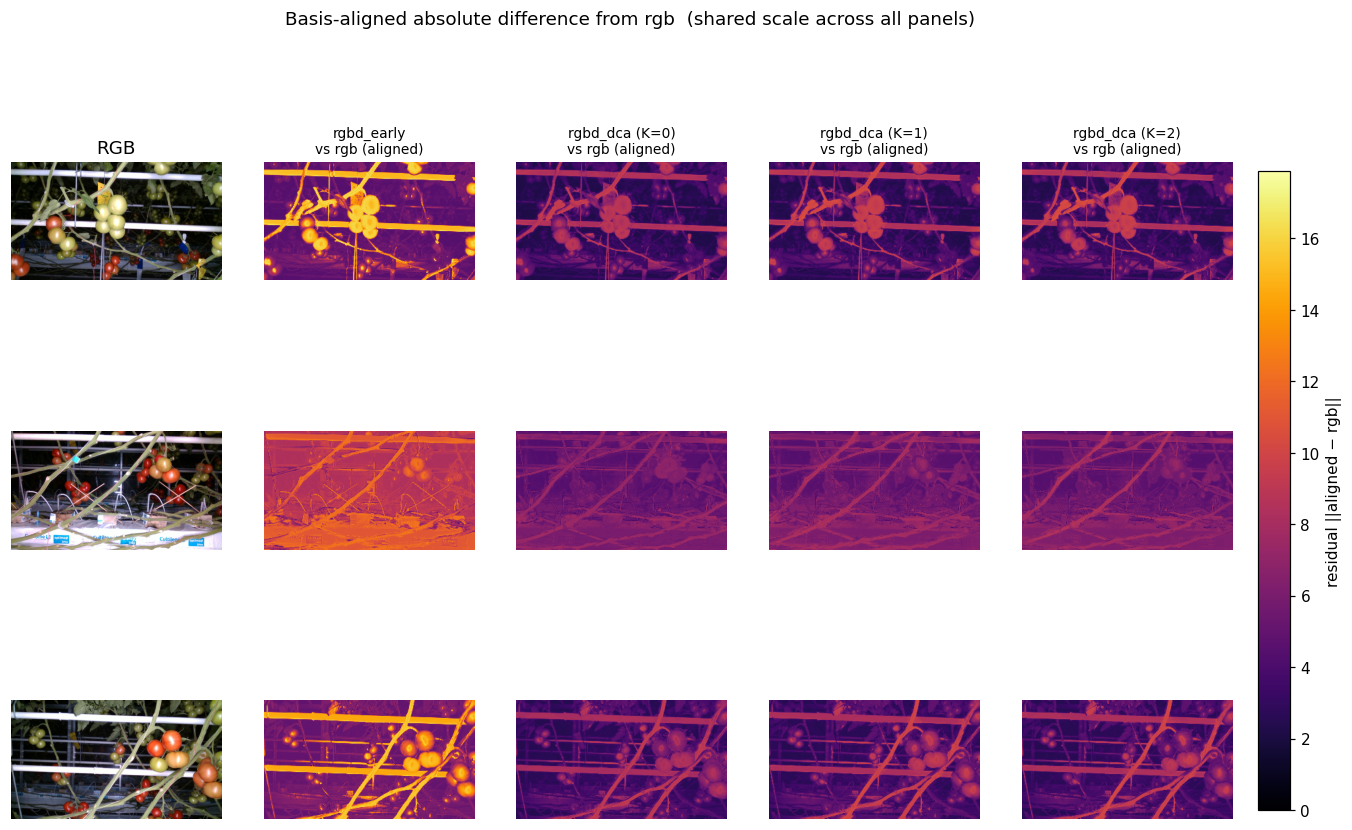

In [15]:
# Basis-aligned residual across several images, with a SHARED colour scale so
# both rows and columns are directly comparable in absolute terms.
panel_names = [n for n in RUNS if n != 'rgb']

# First pass: compute every residual map, track a global vmax for shared scaling.
maps, rgbs = {}, {}
gmax = 0.0
for nm in IMAGE_NAMES:
    ti, rgb_i, _, _ = load_input(nm)
    rgbs[nm] = rgb_i
    ref_tok, _ = tokens_np('rgb', ti)
    for name in panel_names:
        var_tok, g = tokens_np(name, ti)
        resid, _ = procrustes_residual(var_tok, ref_tok)
        m = resid.reshape(*g)
        maps[(nm, name)] = m
        gmax = max(gmax, float(m.max()))

fig, ax = plt.subplots(len(IMAGE_NAMES), len(panel_names) + 1,
                       figsize=(3.0 * (len(panel_names) + 1), 3.0 * len(IMAGE_NAMES)))
ax = np.atleast_2d(ax)
im = None
for ri, nm in enumerate(IMAGE_NAMES):
    ax[ri, 0].imshow(rgbs[nm]); ax[ri, 0].axis('off')
    if ri == 0:
        ax[ri, 0].set_title('RGB')
    for ci, name in enumerate(panel_names, start=1):
        im = ax[ri, ci].imshow(maps[(nm, name)], cmap='inferno', vmin=0, vmax=gmax)
        ax[ri, ci].axis('off')
        if ri == 0:
            ax[ri, ci].set_title(f'{name}\nvs rgb (aligned)', fontsize=9)
fig.suptitle('Basis-aligned absolute difference from rgb  (shared scale across all panels)')
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='residual ||aligned − rgb||')
plt.show()